# LDA ↔ IRS organization matching

Resolve LDA lobbying organizations (client / registrant / affiliate) to IRS Form 990 EINs, reading Parquet directly from S3.

For each fee-bearing filing we build org-name candidates per role, normalize names the same way as the IRS extract, then match to IRS `organizations` by **exact** and **near** (Jaro-Winkler) name. Each match is graded by the strongest corroborating evidence:

All matches are reviewable candidates, not approved identity assertions.

- **name** — normalized names match only

- **name + state** — plus the org's state (or principal place of business) agrees- **name + state + zip** — plus the 5-digit ZIP agrees (strongest)

In [ ]:
from pathlib import Path
import duckdb

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARQUET_BASE = "s3://irs-990-263839540825-us-east-2-an/parquet_updated"
AWS_REGION = "us-east-2"

conn = duckdb.connect(database=":memory:")
conn.execute("INSTALL httpfs; LOAD httpfs;")
conn.execute(f"""
    CREATE SECRET s3_access (
        TYPE s3,
        PROVIDER credential_chain,
        REGION '{AWS_REGION}'
    )
""")

for table in (
    "organizations",
    "irs_master",
    "irs990_filings",
    "irs990_filing_related_orgs",
    "irs990_filing_527_orgs",
    "lda_filings",
    "entity_observations",
):
    conn.execute(f"""
        CREATE OR REPLACE VIEW {table} AS
        SELECT *
        FROM read_parquet(
            '{PARQUET_BASE}/{table}/*.parquet',
            union_by_name = true
        )
    """)

def q(sql):
    return conn.execute(sql).df()

coverage = q("""
SELECT 1 AS sort_order, 'Form 990 e-file organization EINs' AS metric,
       COUNT(DISTINCT ein) AS value
FROM organizations
UNION ALL
SELECT 2, 'EINs in current loaded IRS master extract', COUNT(DISTINCT ein)
FROM irs_master
UNION ALL
SELECT 3, 'Current IRS master EINs with state', COUNT(DISTINCT ein)
FROM irs_master
WHERE NULLIF(TRIM(state), '') IS NOT NULL
UNION ALL
SELECT 4, 'Form 990 filing EINs with filing state', COUNT(DISTINCT ein)
FROM irs990_filings
WHERE NULLIF(TRIM(CAST(filer_state AS VARCHAR)), '') IS NOT NULL
UNION ALL
SELECT 5, 'Schedule R related-org EINs with state',
       COUNT(DISTINCT ein)
FROM irs990_filing_related_orgs
WHERE NULLIF(TRIM(ein), '') IS NOT NULL
  AND NULLIF(TRIM(state_code), '') IS NOT NULL
UNION ALL
SELECT 6, '527-org EINs with state', COUNT(DISTINCT ein)
FROM irs990_filing_527_orgs
WHERE NULLIF(TRIM(ein), '') IS NOT NULL
  AND NULLIF(TRIM(state_code), '') IS NOT NULL
UNION ALL
SELECT 7, 'LDA filings', COUNT(*) FROM lda_filings
UNION ALL
SELECT 8, 'LDA filings with client state', COUNT(*)
FROM lda_filings
WHERE json_valid(raw_json)
  AND NULLIF(TRIM(json_extract_string(raw_json, '$.client.state')), '') IS NOT NULL
UNION ALL
SELECT 9, 'Distinct LDA client IDs',
       COUNT(DISTINCT json_extract_string(raw_json, '$.client.id'))
FROM lda_filings WHERE json_valid(raw_json)
UNION ALL
SELECT 10, 'Distinct LDA client IDs with state',
       COUNT(DISTINCT CASE
           WHEN NULLIF(TRIM(json_extract_string(raw_json, '$.client.state')), '') IS NOT NULL
           THEN json_extract_string(raw_json, '$.client.id') END)
FROM lda_filings WHERE json_valid(raw_json)
ORDER BY sort_order
""").drop(columns="sort_order")

print(f"DuckDB reading updated Parquet from: {PARQUET_BASE}")
coverage.style.format({"value": "{:,.0f}"})

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

DuckDB reading updated Parquet from: s3://irs-990-263839540825-us-east-2-an/parquet_updated


,metric,value
0,Form 990 e-file organization EINs,"861,081"
1,EINs in current loaded IRS master extract,"279,802"
2,Current IRS master EINs with state,"279,802"
3,Form 990 filing EINs with filing state,"860,890"
4,Schedule R related-org EINs with state,"193,996"
5,527-org EINs with state,"10,530"
6,LDA filings,"192,174"
7,LDA filings with client state,"186,203"
8,Distinct LDA client IDs,"28,790"
9,Distinct LDA client IDs with state,"27,845"


In [12]:
import re as _re

# Shared helpers so the matching cells below don't repeat the same logic:
#   NEAR_NAME_MIN_SIMILARITY - single source of truth for the near-name cutoff
#   norm_org      - org-name normalization matching extract/entities.py
#   name_block_on - blocked Jaro-Winkler join predicate (shared 8-char prefix + length ratio)
#   tier_case     - name / name+state / name+state+zip label from zip_agrees / state_agrees
NEAR_NAME_MIN_SIMILARITY = 0.85

_NOISE = {
    "inc", "incorporated", "llc", "lp", "llp", "corp", "corporation",
    "the", "of", "and", "for", "a", "an", "pac", "cmte", "association", "committee", "fund", "foundation", "trust", "club"
}

def _norm_org(name):
    if not name:
        return ""
    tokens = _re.sub(r"[^a-z0-9\s]", " ", name.lower()).split()
    return " ".join(t for t in tokens if t not in _NOISE)

try:
    conn.create_function("norm_org", _norm_org, ["VARCHAR"], "VARCHAR")
except Exception:
    pass  # already registered in this kernel

def name_block_on(a, b):
    """Blocking predicate for near-name joins: shared 8-char prefix and >=60% length ratio."""
    return (
        f"LEFT({a}, 8) = LEFT({b}, 8)\n"
        f"     AND LEAST(LENGTH({a}), LENGTH({b}))::DOUBLE\n"
        f"         / GREATEST(LENGTH({a}), LENGTH({b})) >= 0.60"
    )

def tier_case(prefix="name"):
    """Strongest-evidence label from the zip_agrees / state_agrees booleans."""
    return (
        "CASE "
        f"WHEN zip_agrees THEN '{prefix} + state + zip' "
        f"WHEN state_agrees THEN '{prefix} + state' "
        f"ELSE '{prefix} only' END"
    )


In [13]:
# IRS EIN-level entities: name, normalized name, and best-available state
# (latest Form 990 filing state; else BMF master; else Schedule R; else 527).
conn.execute("""
CREATE OR REPLACE TEMP TABLE irs_entities AS
WITH ranked_filing_states AS (
    SELECT
        ein,
        UPPER(NULLIF(TRIM(CAST(filer_state AS VARCHAR)), '')) AS filing_state,
        ROW_NUMBER() OVER (
            PARTITION BY ein
            ORDER BY
                COALESCE(return_timestamp, tax_period_end_date, CAST(tax_year AS VARCHAR)) DESC,
                filing_id DESC
        ) AS state_recency
    FROM irs990_filings
    WHERE NULLIF(TRIM(CAST(filer_state AS VARCHAR)), '') IS NOT NULL
), filing_states AS (
    SELECT ein, filing_state FROM ranked_filing_states WHERE state_recency = 1
), related_states AS (
    SELECT ein, mode(UPPER(TRIM(state_code))) AS related_state
    FROM irs990_filing_related_orgs
    WHERE NULLIF(TRIM(ein), '') IS NOT NULL AND NULLIF(TRIM(state_code), '') IS NOT NULL
    GROUP BY ein
), p527_states AS (
    SELECT ein, mode(UPPER(TRIM(state_code))) AS p527_state
    FROM irs990_filing_527_orgs
    WHERE NULLIF(TRIM(ein), '') IS NOT NULL AND NULLIF(TRIM(state_code), '') IS NOT NULL
    GROUP BY ein
)
SELECT
    organization.ein,
    organization.current_name AS irs_name,
    organization.normalized_name,
    COALESCE(
        filing.filing_state,
        UPPER(NULLIF(TRIM(master.state), '')),
        related.related_state,
        p527.p527_state
    ) AS irs_state
FROM organizations AS organization
LEFT JOIN filing_states AS filing USING (ein)
LEFT JOIN irs_master AS master USING (ein)
LEFT JOIN related_states AS related USING (ein)
LEFT JOIN p527_states AS p527 USING (ein)
WHERE organization.normalized_name IS NOT NULL
  AND organization.normalized_name <> ''
""")

print("IRS entities:", f"{q('SELECT COUNT(*) AS n FROM irs_entities').iloc[0]['n']:,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

IRS entities: 861,079


## LDA org candidates (client / registrant / affiliate)

Keep filings with lobbying fees (`income` or `expenses` > 0). Build one candidate per (role, org): the **client** being represented, the **registrant** (self-filer / in-house), and any **affiliate**. The LDA client object carries no ZIP, so a client ZIP is borrowed from any filing where the org self-files, keyed by name + state so a same-name org elsewhere can't donate the wrong ZIP.

In [ ]:
# norm_org UDF is registered in the shared-helpers cell near the top of the notebook.
conn.execute("""
CREATE OR REPLACE TEMP TABLE lda_fee_filings AS
SELECT
    filing_uuid,
    json_extract_string(raw_json, '$.client.id')   AS client_id,
    json_extract_string(raw_json, '$.client.name') AS client_name,
    UPPER(NULLIF(TRIM(json_extract_string(raw_json, '$.client.state')), '')) AS client_state,
    UPPER(NULLIF(TRIM(json_extract_string(raw_json, '$.client.ppb_state')), '')) AS client_ppb_state,
    json_extract_string(raw_json, '$.registrant.name') AS registrant_name,
    UPPER(NULLIF(TRIM(json_extract_string(raw_json, '$.registrant_state')), '')) AS registrant_state,
    LEFT(NULLIF(TRIM(json_extract_string(raw_json, '$.registrant_zip')), ''), 5) AS registrant_zip5,
    raw_json
FROM lda_filings
WHERE json_valid(raw_json)
  AND (COALESCE(income, 0) > 0 OR COALESCE(expenses, 0) > 0)
""")

# One candidate per (role, org) with the org's normalized name and available location.
# The LDA client object carries no ZIP, so a client ZIP is only available when the org
# self-files (registrant name normalizes to the client name). self_filed_zip learns that
# ZIP and backfills it onto the org's outside-firm filings, keyed by name + state so a
# same-name org in another state can never donate the wrong ZIP.
conn.execute("""
CREATE OR REPLACE TEMP TABLE lda_org_candidates AS
WITH self_filed_zip AS (
    SELECT norm_org(client_name) AS client_norm,
           registrant_state AS self_state,
           mode(registrant_zip5) AS self_zip5
    FROM lda_fee_filings
    WHERE norm_org(client_name) = norm_org(registrant_name)
      AND registrant_zip5 IS NOT NULL
      AND registrant_state IS NOT NULL
    GROUP BY norm_org(client_name), registrant_state
), client_role AS (
    SELECT
        'client' AS role,
        f.client_id AS lda_key,
        f.client_name AS lda_name,
        norm_org(f.client_name) AS normalized_name,
        f.client_state AS lda_state,
        f.client_ppb_state AS lda_ppb_state,
        COALESCE(
            CASE WHEN norm_org(f.client_name) = norm_org(f.registrant_name)
                 THEN f.registrant_zip5 END,
            sz.self_zip5
        ) AS lda_zip
    FROM lda_fee_filings AS f
    LEFT JOIN self_filed_zip AS sz
      ON sz.client_norm = norm_org(f.client_name)
     AND sz.self_state IN (f.client_state, f.client_ppb_state)
), registrant_role AS (
    SELECT
        'registrant',
        registrant_name,
        registrant_name,
        norm_org(registrant_name),
        registrant_state,
        NULL,
        registrant_zip5
    FROM lda_fee_filings
), affiliate_role AS (
    SELECT
        'affiliate',
        json_extract_string(a.value, '$.name'),   -- lda_key (affiliates have no stable id, reuse name)
        json_extract_string(a.value, '$.name'),   -- lda_name
        norm_org(json_extract_string(a.value, '$.name')),
        UPPER(NULLIF(TRIM(json_extract_string(a.value, '$.state')), '')),
        UPPER(NULLIF(TRIM(json_extract_string(a.value, '$.ppb_state')), '')),
        LEFT(NULLIF(TRIM(json_extract_string(a.value, '$.zip')), ''), 5)
    FROM lda_fee_filings,
         json_each(json_extract(raw_json, '$.affiliated_organizations')) AS a
)
SELECT DISTINCT *
FROM (
    SELECT * FROM client_role
    UNION ALL SELECT * FROM registrant_role
    UNION ALL SELECT * FROM affiliate_role
) AS all_roles
WHERE normalized_name IS NOT NULL
  AND LEN(STRING_SPLIT(normalized_name, ' ')) >= 2
""")

candidate_counts = q("""
SELECT role,
       COUNT(*) AS candidate_rows,
       COUNT(DISTINCT lda_key) AS distinct_orgs,
       COUNT(DISTINCT lda_key) FILTER (WHERE lda_zip IS NOT NULL) AS orgs_with_zip
FROM lda_org_candidates
GROUP BY role
ORDER BY role
""")
candidate_counts.style.format({
    "candidate_rows": "{:,.0f}",
    "distinct_orgs": "{:,.0f}",
    "orgs_with_zip": "{:,.0f}",
})

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [16]:
# IRS entities with a 5-digit ZIP from their most recent filing, for ZIP agreement.
conn.execute("""
CREATE OR REPLACE TEMP TABLE irs_entities_addr AS
WITH latest AS (
    SELECT
        ein,
        LEFT(NULLIF(TRIM(CAST(filer_zip AS VARCHAR)), ''), 5) AS filer_zip5,
        ROW_NUMBER() OVER (
            PARTITION BY ein
            ORDER BY COALESCE(return_timestamp, tax_period_end_date, CAST(tax_year AS VARCHAR)) DESC,
                     filing_id DESC
        ) AS rn
    FROM irs990_filings
    WHERE NULLIF(TRIM(CAST(filer_zip AS VARCHAR)), '') IS NOT NULL
)
SELECT irs.ein, irs.irs_name, irs.normalized_name, irs.irs_state,
       latest.filer_zip5 AS irs_zip
FROM irs_entities AS irs
LEFT JOIN latest ON latest.ein = irs.ein AND latest.rn = 1
""")

conn.execute("""
CREATE OR REPLACE TEMP TABLE role_matches AS
SELECT
    cand.role,
    cand.lda_key,
    cand.lda_name,
    cand.normalized_name,
    cand.lda_state,
    cand.lda_ppb_state,
    cand.lda_zip,
    irs.ein,
    irs.irs_name,
    irs.irs_state,
    irs.irs_zip,
    (irs.irs_state IN (cand.lda_state, cand.lda_ppb_state)
        AND irs.irs_state IS NOT NULL) AS state_agrees,
    (cand.lda_zip IS NOT NULL AND cand.lda_zip = irs.irs_zip) AS zip_agrees
FROM lda_org_candidates AS cand
JOIN irs_entities_addr AS irs USING (normalized_name)
""")

role_match_summary = q("""
SELECT
    role,
    COUNT(DISTINCT lda_key) AS matched_orgs,
    COUNT(DISTINCT ein) AS irs_eins,
    COUNT(DISTINCT lda_key) FILTER (WHERE state_agrees) AS state_agree_orgs,
    COUNT(DISTINCT lda_key) FILTER (WHERE zip_agrees) AS zip_agree_orgs
FROM role_matches
GROUP BY role
ORDER BY role
""")
role_match_summary.style.format({
    "matched_orgs": "{:,.0f}",
    "irs_eins": "{:,.0f}",
    "state_agree_orgs": "{:,.0f}",
    "zip_agree_orgs": "{:,.0f}",
})

,role,matched_orgs,irs_eins,state_agree_orgs,zip_agree_orgs
0,affiliate,25,25,23,0
1,client,"3,189","4,039","2,688",987
2,registrant,653,"1,861",557,503


## Near-name role matching with state / ZIP agreement

The role-tagged `role_matches` table above uses **exact** normalized-name equality. This section adds the **near-name** layer for all three roles (client / registrant / affiliate), reusing the same blocked Jaro-Winkler rules as the client-only near-name stage:

- share the first eight normalized characters,
- shorter name at least 60% of the longer,
- Jaro-Winkler similarity ≥ `NEAR_NAME_MIN_SIMILARITY` (0.85),
- exact equality excluded (already captured by `role_matches`).

Each near-name candidate then gets the same **state** (`state` or `ppb_state`) and **5-digit ZIP** agreement flags. A ZIP or state agreement on a near-name match is a strong review signal; near-name alone is weaker and stays a manual-review candidate.


In [17]:
# Near-name role matching: same block + Jaro-Winkler rules, then state / ZIP agreement.
# Excludes exact normalized-name equality (already covered by role_matches).
conn.execute(f"""
CREATE OR REPLACE TEMP TABLE role_near_matches AS
WITH blocked AS (
    SELECT
        cand.role,
        cand.lda_key,
        cand.lda_name,
        cand.normalized_name AS lda_normalized_name,
        cand.lda_state,
        cand.lda_ppb_state,
        cand.lda_zip,
        irs.ein,
        irs.irs_name,
        irs.normalized_name AS irs_normalized_name,
        irs.irs_state,
        irs.irs_zip,
        jaro_winkler_similarity(cand.normalized_name, irs.normalized_name) AS name_similarity
    FROM lda_org_candidates AS cand
    JOIN irs_entities_addr AS irs
      ON {name_block_on('cand.normalized_name', 'irs.normalized_name')}
     AND cand.normalized_name <> irs.normalized_name
    WHERE jaro_winkler_similarity(cand.normalized_name, irs.normalized_name)
          >= {NEAR_NAME_MIN_SIMILARITY}
)
SELECT *,
    (irs_state IN (lda_state, lda_ppb_state) AND irs_state IS NOT NULL) AS state_agrees,
    (lda_zip IS NOT NULL AND lda_zip = irs_zip) AS zip_agrees
FROM blocked
""")

role_near_summary = q(f"""
WITH labeled AS (
    SELECT *, {tier_case('near-name')} AS confidence
    FROM role_near_matches
)
SELECT
    confidence,
    role,
    COUNT(*) AS candidate_links,
    COUNT(DISTINCT lda_key) AS lda_orgs,
    COUNT(DISTINCT ein) AS irs_eins,
    ROUND(AVG(name_similarity), 3) AS avg_similarity
FROM labeled
GROUP BY confidence, role
ORDER BY
    CASE confidence WHEN 'near-name + state + zip' THEN 1
                    WHEN 'near-name + state' THEN 2 ELSE 3 END,
    role
""")
display(role_near_summary.style.format({
    "candidate_links": "{:,.0f}",
    "lda_orgs": "{:,.0f}",
    "irs_eins": "{:,.0f}",
    "avg_similarity": "{:.3f}",
}))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,confidence,role,candidate_links,lda_orgs,irs_eins,avg_similarity
0,near-name + state + zip,client,"8,654","1,844","2,109",0.874
1,near-name + state + zip,registrant,"4,305",926,"2,190",0.874
2,near-name + state,affiliate,"1,441",74,"1,328",0.867
3,near-name + state,client,"230,340","7,448","51,593",0.867
4,near-name + state,registrant,"43,402","1,240","16,603",0.866
5,near-name only,affiliate,"20,037",103,"12,499",0.865
6,near-name only,client,"2,149,793","10,137","120,896",0.865
7,near-name only,registrant,"570,790","2,195","68,674",0.866


In [18]:
# High-confidence LDA<->IRS cohort for the network step.
# One row per (role, org): best EIN at name_similarity >= HIGH_CONF_MIN, tier = name+state+zip else name+state.
HIGH_CONF_MIN = 0.9

conn.execute("""
CREATE OR REPLACE TEMP TABLE all_role_matches AS
SELECT role, lda_key, lda_name, ein, irs_name, 1.0 AS name_similarity,
       lda_state, irs_state, lda_zip, irs_zip, state_agrees, zip_agrees
FROM role_matches
UNION ALL
SELECT role, lda_key, lda_name, ein, irs_name, name_similarity,
       lda_state, irs_state, lda_zip, irs_zip, state_agrees, zip_agrees
FROM role_near_matches
""")

conn.execute(f"""
CREATE OR REPLACE TEMP TABLE high_conf_matches AS
WITH ranked AS (
    SELECT role, lda_key, lda_name, ein, irs_name, name_similarity,
           lda_state, irs_state, lda_zip, irs_zip, zip_agrees,
           ROW_NUMBER() OVER (
               PARTITION BY role, lda_key
               ORDER BY zip_agrees DESC, state_agrees DESC, name_similarity DESC, ein
           ) AS rn
    FROM all_role_matches
    WHERE name_similarity >= {HIGH_CONF_MIN} AND (state_agrees OR zip_agrees)
)
SELECT role, lda_key, lda_name, ein, irs_name,
       ROUND(name_similarity, 4) AS name_similarity,
       lda_state, irs_state, lda_zip, irs_zip,
       CASE WHEN zip_agrees THEN 'name+state+zip' ELSE 'name+state' END AS tier
FROM ranked WHERE rn = 1
""")

high_conf_matches = q("SELECT * FROM high_conf_matches ORDER BY tier, role, lda_name")
print(f"high-confidence matches (similarity >= {HIGH_CONF_MIN}): "
      f"{len(high_conf_matches):,} orgs, {high_conf_matches['ein'].nunique():,} distinct EINs")
print(high_conf_matches.groupby(["tier", "role"]).size().to_string())
display(high_conf_matches)


high-confidence matches (similarity >= 0.9): 7,084 orgs, 4,049 distinct EINs
tier            role      
name+state      affiliate       54
                client        4180
                registrant     254
name+state+zip  client        1739
                registrant     857


,role,lda_key,lda_name,ein,irs_name,name_similarity,lda_state,irs_state,lda_zip,irs_zip,tier
0,affiliate,"AMAC ACTION, INC.","AMAC ACTION, INC.",900678436,AMAC-ACTION INC,1.0000,FL,FL,None,34748,name+state
1,affiliate,AMERICAN EXPRESS,AMERICAN EXPRESS,810817252,AMERICAN PASSAGE INC,0.9096,NY,NY,None,10510,name+state
2,affiliate,AMERICAN FOREST FOUNDATION,AMERICAN FOREST FOUNDATION,943031987,AMERICAN FOUNDRY SOCIETY,0.9117,WA,WA,None,98188,name+state
3,affiliate,AMERICAN INTERNATIONAL GROUP (AIG),AMERICAN INTERNATIONAL GROUP (AIG),812838839,AMERICAN INTERNATIONAL DEVELOPMENT FOUNDATION INC,0.9032,NY,NY,None,10013,name+state
4,affiliate,AMERICAN SOCIETY OF CIVIL ENGINEERS,AMERICAN SOCIETY OF CIVIL ENGINEERS,132798416,AMERICAN SOCIETY OF INTERIOR DESIGNERS,0.9125,DC,DC,None,20005,name+state
...,...,...,...,...,...,...,...,...,...,...,...
7079,registrant,YALE UNIVERSITY,YALE UNIVERSITY,060646973,Yale University,1.0000,CT,CT,06520,06520,name+state+zip
7080,registrant,YWCA USA,YWCA USA,131624103,YWCA USA INC,1.0000,DC,DC,20005,20005,name+state+zip
7081,registrant,ZERO EMISSION TRANSPORTATION ASSOCIATION,ZERO EMISSION TRANSPORTATION ASSOCIATION,852297985,ZERO EMISSION TRANSPORTATION ASSOC,0.9647,DC,DC,20003,20003,name+state+zip
7082,registrant,ZERO PROSTATE CANCER,ZERO PROSTATE CANCER,593400922,ZERO PROSTATE CANCER,1.0000,VA,VA,22314,22314,name+state+zip


In [19]:
# What downstream data is available for the matched orgs -> inputs for the network step.
for t in ("irs990_filing_grants", "irs990_filing_people", "irs990_filing_related_orgs",
          "irs990_filing_related_org_transactions", "irs990_filing_contractors",
          "irs990_filing_lobbying", "lobbying_bill_links", "lda_lobbying_activities"):
    conn.execute(f"""CREATE OR REPLACE VIEW {t} AS
        SELECT * FROM read_parquet('{PARQUET_BASE}/{t}/*.parquet', union_by_name=true)""")

# Form 990 filings belonging to the matched EINs (filing_id is the join key for filing_* tables).
conn.execute("""
CREATE OR REPLACE TEMP TABLE matched_ein_filings AS
SELECT DISTINCT f.filing_id, f.ein
FROM irs990_filings f
JOIN (SELECT DISTINCT ein FROM high_conf_matches) m USING (ein)
""")

# IRS-side: edges/attributes attachable to the matched EINs.
irs_inventory = q("""
SELECT 'Form 990 base attributes (revenue, assets, mission)' AS dataset, 'ein' AS join_key,
       COUNT(DISTINCT ein) AS matched_eins_covered, COUNT(*) AS rows
FROM matched_ein_filings
UNION ALL
SELECT 'Grants made (org -> grantee edges)', 'filing_id->ein',
       COUNT(DISTINCT mf.ein), COUNT(*)
FROM irs990_filing_grants g JOIN matched_ein_filings mf USING (filing_id)
UNION ALL
SELECT 'Officers / directors (people, shared-person edges)', 'filing_id->ein',
       COUNT(DISTINCT mf.ein), COUNT(*)
FROM irs990_filing_people p JOIN matched_ein_filings mf USING (filing_id)
UNION ALL
SELECT 'Related orgs (parent / subsidiary edges)', 'filing_id->ein',
       COUNT(DISTINCT mf.ein), COUNT(*)
FROM irs990_filing_related_orgs r JOIN matched_ein_filings mf USING (filing_id)
UNION ALL
SELECT 'Related-org transactions ($ flows)', 'filing_id->ein',
       COUNT(DISTINCT mf.ein), COUNT(*)
FROM irs990_filing_related_org_transactions rt JOIN matched_ein_filings mf USING (filing_id)
UNION ALL
SELECT 'Contractors', 'filing_id->ein',
       COUNT(DISTINCT mf.ein), COUNT(*)
FROM irs990_filing_contractors c JOIN matched_ein_filings mf USING (filing_id)
UNION ALL
SELECT 'Lobbying spend (Schedule C)', 'filing_id->ein',
       COUNT(DISTINCT mf.ein), COUNT(*)
FROM irs990_filing_lobbying l JOIN matched_ein_filings mf USING (filing_id)
ORDER BY matched_eins_covered DESC
""")
print("IRS-side data available for the 3,235 matched EINs:")
display(irs_inventory.style.format({"matched_eins_covered": "{:,.0f}", "rows": "{:,.0f}"}))

# Grants that point to ANOTHER matched org = ready-made org->org money edges.
grant_edges = q("""
SELECT COUNT(*) AS grant_rows,
       COUNT(*) FILTER (WHERE g.grantee_ein IN (SELECT ein FROM high_conf_matches))
           AS edges_between_matched_orgs
FROM irs990_filing_grants g JOIN matched_ein_filings mf USING (filing_id)
""")
print("\nGrant edges:")
display(grant_edges.style.format("{:,.0f}"))

# LDA-side: lobbied bills + issue areas attachable to the matched client orgs.
lda_inventory = q("""
WITH matched_clients AS (
    SELECT DISTINCT lda_key FROM high_conf_matches WHERE role = 'client'
),
client_filings AS (
    SELECT json_extract_string(raw_json, '$.client.id') AS lda_key, filing_uuid
    FROM lda_filings WHERE json_valid(raw_json)
)
SELECT
    COUNT(DISTINCT mc.lda_key) AS matched_client_orgs,
    COUNT(DISTINCT cf.filing_uuid) AS lda_filings,
    COUNT(DISTINCT bl.link_id) AS bill_links,
    COUNT(DISTINCT (bl.bill_type, bl.bill_number)) AS distinct_bills,
    COUNT(DISTINCT act.general_issue_code) AS issue_areas
FROM matched_clients mc
JOIN client_filings cf USING (lda_key)
LEFT JOIN lobbying_bill_links bl USING (filing_uuid)
LEFT JOIN lda_lobbying_activities act USING (filing_uuid)
""")
print("\nLDA-side data available for matched client orgs:")
display(lda_inventory.style.format("{:,.0f}"))

IRS-side data available for the 3,235 matched EINs:


,dataset,join_key,matched_eins_covered,rows
0,"Form 990 base attributes (revenue, assets, mission)",ein,"4,049","28,102"
1,"Officers / directors (people, shared-person edges)",filing_id->ein,"3,997","565,716"
2,Lobbying spend (Schedule C),filing_id->ein,"2,754","15,569"
3,Contractors,filing_id->ein,"2,418","50,789"
4,Related orgs (parent / subsidiary edges),filing_id->ein,"1,986","110,892"
5,Grants made (org -> grantee edges),filing_id->ein,"1,828","757,332"
6,Related-org transactions ($ flows),filing_id->ein,"1,410","57,718"



Grant edges:


,grant_rows,edges_between_matched_orgs
0,"757,332","32,829"


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


LDA-side data available for matched client orgs:


,matched_client_orgs,lda_filings,bill_links,distinct_bills,issue_areas
0,"5,919","42,491","131,429","9,308",79


# Network analysis

Two graphs over the  high-confidence cohort:

- **Funding network** — directed org → org edges from Form 990 grants where the grantee is also a matched org, weighted by dollars. PageRank surfaces the biggest downstream recipients of grant money.
- **Co-lobbying network** — orgs connected when they lobby the same bills (bipartite org↔bill projected to org–org, weighted by shared bills). Mega-bills touched by >100 orgs are dropped to keep the graph meaningful. PageRank and betweenness surface central players and cross-issue brokers; Louvain communities reveal issue coalitions.


In [10]:
import math
import networkx as nx
import pandas as pd
try:
    import community as community_louvain
except Exception:
    community_louvain = None

# EIN -> IRS name label map for readable node output.
ein_name = dict(high_conf_matches.drop_duplicates("ein")[["ein", "irs_name"]].values)

# ---- Funding network: grantor EIN -> grantee EIN, both inside the matched cohort ----
funding_edges = q("""
SELECT mf.ein AS src_ein, g.grantee_ein AS dst_ein,
       COUNT(*) AS n_grants, SUM(TRY_CAST(g.amount AS DOUBLE)) AS total_amount
FROM irs990_filing_grants g
JOIN matched_ein_filings mf USING (filing_id)
WHERE g.grantee_ein IN (SELECT ein FROM high_conf_matches)
  AND g.grantee_ein <> mf.ein
GROUP BY mf.ein, g.grantee_ein
""")

FG = nx.DiGraph()
for r in funding_edges.itertuples(index=False):
    amt = float(r.total_amount or 0.0)
    if not math.isfinite(amt) or amt < 0:
        amt = 0.0
    FG.add_edge(r.src_ein, r.dst_ein, weight=math.log1p(amt), amount=amt, n=int(r.n_grants))
# log-scaled weights keep PageRank stable across the huge dollar range.
f_pagerank = nx.pagerank(FG, weight="weight", max_iter=500)
f_dollars_in = dict(FG.in_degree(weight="amount"))
funding_top = (
    pd.DataFrame({"ein": list(f_pagerank), "pagerank": list(f_pagerank.values())})
    .assign(org=lambda d: d.ein.map(ein_name),
            dollars_received=lambda d: d.ein.map(f_dollars_in))
    .sort_values("pagerank", ascending=False).head(15)
)
print(f"Funding network: {FG.number_of_nodes():,} orgs, {FG.number_of_edges():,} edges")
display(funding_top[["org", "ein", "pagerank", "dollars_received"]])

# ---- Co-lobbying network: orgs linked by shared bills (cap mega-bills to keep it sparse) ----
org_bill = q("""
WITH client_ein AS (SELECT DISTINCT lda_key, ein FROM high_conf_matches WHERE role = 'client'),
     client_filings AS (
        SELECT json_extract_string(raw_json, '$.client.id') AS lda_key, filing_uuid
        FROM lda_filings WHERE json_valid(raw_json)),
     ob AS (
        SELECT DISTINCT ce.ein AS ein,
               bl.bill_type || CAST(bl.bill_number AS VARCHAR) AS bill
        FROM client_ein ce
        JOIN client_filings cf USING (lda_key)
        JOIN lobbying_bill_links bl USING (filing_uuid)
        WHERE bl.bill_number IS NOT NULL),
     bill_deg AS (SELECT bill, COUNT(*) AS n_orgs FROM ob GROUP BY bill)
SELECT ob.ein, ob.bill
FROM ob JOIN bill_deg USING (bill)
WHERE bill_deg.n_orgs BETWEEN 2 AND 100
""")

orgs = org_bill.ein.unique().tolist()
B = nx.Graph()
B.add_nodes_from(orgs, bipartite=0)
B.add_nodes_from(org_bill.bill.unique().tolist(), bipartite=1)
B.add_edges_from(map(tuple, org_bill[["ein", "bill"]].values))
CL = nx.bipartite.weighted_projected_graph(B, orgs)

c_pagerank = nx.pagerank(CL, weight="weight", max_iter=500)
c_betweenness = nx.betweenness_centrality(CL, k=min(300, CL.number_of_nodes()), seed=1)
parts = community_louvain.best_partition(CL, weight="weight") if community_louvain else {}
colobby_top = (
    pd.DataFrame({"ein": list(c_pagerank)})
    .assign(org=lambda d: d.ein.map(ein_name),
            pagerank=lambda d: d.ein.map(c_pagerank),
            betweenness=lambda d: d.ein.map(c_betweenness),
            community=lambda d: d.ein.map(parts))
    .sort_values("pagerank", ascending=False).head(15)
)
n_comm = len(set(parts.values())) if parts else 0
print(f"\nCo-lobbying network: {CL.number_of_nodes():,} orgs, {CL.number_of_edges():,} edges, {n_comm} communities")
display(colobby_top[["org", "ein", "pagerank", "betweenness", "community"]])

Funding network: 1,856 orgs, 9,423 edges


,org,ein,pagerank,dollars_received
196,UNIVERSITY OF NORTH CAROLINA AT CHAPEL HILL,566001393,0.007251,4.877249e+08
149,JOHNS HOPKINS UNIVERSITY,520595110,0.006387,9.425090e+08
240,MARCH OF DIMES INC,131846366,0.006081,7.357681e+06
143,TRUSTEES OF THE UNIVERSITY OF PENNSYLVANIA,231352685,0.005362,4.162504e+08
120,UNIVERSITY OF SOUTHERN CALIFORNIA,951642394,0.005193,4.759542e+08
79,New York University,135562308,0.005071,3.193768e+08
156,The Regents of the University of Colorado,846000555,0.004095,4.752011e+08
30,REGENTS OF THE UNIVERSITY OF MICHIGAN,386006309,0.004073,7.079365e+08
33,DUKE UNIVERSITY,560532129,0.004029,5.758129e+08
93,THE TRUSTEES OF COLUMBIA UNIVERSITY IN THE CIT...,135598093,0.004016,2.555427e+08


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Co-lobbying network: 1,690 orgs, 104,073 edges, 9 communities


,org,ein,pagerank,betweenness,community
47,Chamber of Commerce of the USA,530045720,0.011501,0.065460,4
1,NATIONAL TREASURY EMPLOYEES UNION,530244795,0.006593,0.014433,1
32,Americans for the Arts Inc,521996467,0.006333,0.031554,3
108,AMERICANS FOR AMERICA Inc,844275594,0.005514,0.016384,3
105,AMERICAN CIVIL LIBERTIES UNION OF THE DISTRICT...,520749684,0.005065,0.014810,4
357,National League for Nursing,131896510,0.004922,0.018406,3
50,AMERICAN CHEMISTRY COUNCIL,530104410,0.004809,0.009540,7
185,HERITAGE ACTION FOR AMERICA,272244700,0.004749,0.012410,7
218,AMERICAN PSYCHIATRIC ASSOCIATION,522168499,0.004562,0.014195,3
26,AMERICAN FEDERATION OF STATE COUNTY AND MUNICI...,530237789,0.004517,0.011447,4


## Network analysis of the 2023/24 money web (all EINs)

Build the **entire** 2023/24 grant network — every `funder → grantee` edge across all filers, weighted by dollars — not just the dark-money neighborhood. The OpenSecrets dark-money EINs are a labeled subset within it. We rank all orgs by **weighted PageRank** and check where the seeds sit: if they concentrate in the high-PageRank core of the whole web, a personalized PageRank seeded on them will surface structurally similar orgs anywhere in the network.

In [21]:
# Build the FULL 2023/24 money-flow network (all EINs) and rank by weighted PageRank; seeds are a labeled subset.
import networkx as nx
import numpy as np, pandas as pd

YEARS = "(2023, 2024)"  # tax years for the money-flow network

# OpenSecrets dark-money seeds (labels within the full web).
conn.execute(f"""CREATE OR REPLACE TEMP TABLE dark_money AS
    SELECT DISTINCT LPAD(CAST(ein AS VARCHAR), 9, '0') AS ein, crp_name
    FROM read_parquet('{(ROOT / "parquet_export" / "crp_dark_money" / "*.parquet").as_posix()}')
    WHERE ein IS NOT NULL""")

# ALL directed grant edges (funder -> grantee) for 2023/24 -- the entire money web, not just seed-adjacent.
edges = q(f"""
WITH fy AS (SELECT filing_id, ein FROM irs990_filings WHERE TRY_CAST(tax_year AS INT) IN {YEARS})
SELECT fy.ein AS src, g.grantee_ein AS dst, SUM(TRY_CAST(g.amount AS DOUBLE)) AS amt
FROM irs990_filing_grants g JOIN fy USING (filing_id)
WHERE g.grantee_ein IS NOT NULL AND g.grantee_ein <> fy.ein
GROUP BY 1, 2
HAVING SUM(TRY_CAST(g.amount AS DOUBLE)) > 0
""")

seed_set = set(conn.execute("SELECT ein FROM dark_money").df().ein)
crp_name = conn.execute("SELECT ein, crp_name FROM dark_money").df().set_index("ein")["crp_name"].to_dict()
org_name = q("SELECT ein, current_name AS name FROM organizations").set_index("ein")["name"].to_dict()
nm = lambda e: (crp_name.get(e) or org_name.get(e) or e)

G = nx.from_pandas_edgelist(edges, "src", "dst", edge_attr="amt", create_using=nx.DiGraph)
pr = nx.pagerank(G, weight="amt")

rank = (pd.DataFrame({"ein": list(G.nodes)})
        .assign(is_seed=lambda d: d.ein.isin(seed_set).astype(int),
                pagerank=lambda d: d.ein.map(pr),
                dollars_in=lambda d: d.ein.map(dict(G.in_degree(weight="amt"))),
                dollars_out=lambda d: d.ein.map(dict(G.out_degree(weight="amt"))),
                in_deg=lambda d: d.ein.map(dict(G.in_degree())),
                out_deg=lambda d: d.ein.map(dict(G.out_degree())))
        .sort_values("pagerank", ascending=False))
rank["name"] = rank.ein.map(nm)
rank["pr_pctile"] = rank.pagerank.rank(pct=True)

n_seed = int(rank.is_seed.sum())
print(f"FULL money web: nodes {G.number_of_nodes():,}   edges {G.number_of_edges():,}   "
      f"total grant $ {edges.amt.sum():,.0f}")
print(f"seeds present {n_seed}/{len(seed_set)}")
print(f"\nSeed centrality within the FULL web (PageRank percentile, 1.0 = most central):")
print(f"  OpenSecrets seeds : median {rank.loc[rank.is_seed==1,'pr_pctile'].median():.3f}  "
      f"mean {rank.loc[rank.is_seed==1,'pr_pctile'].mean():.3f}")
print(f"  everyone else     : median {rank.loc[rank.is_seed==0,'pr_pctile'].median():.3f}  "
      f"mean {rank.loc[rank.is_seed==0,'pr_pctile'].mean():.3f}")

print("\nTop 15 OpenSecrets seeds by PageRank within the full web:")
display(rank[rank.is_seed == 1].head(15)[
    ["name", "pagerank", "pr_pctile", "dollars_in", "dollars_out", "in_deg", "out_deg"]])
print("Top 15 orgs overall by PageRank (largest hubs in the entire money web):")
display(rank.head(15)[["name", "is_seed", "pagerank", "dollars_in", "dollars_out", "in_deg", "out_deg"]])


FULL money web: nodes 436,207   edges 1,184,652   total grant $ 332,368,230,377
seeds present 113/182

Seed centrality within the FULL web (PageRank percentile, 1.0 = most central):
  OpenSecrets seeds : median 0.918  mean 0.811
  everyone else     : median 0.500  mean 0.500

Top 15 OpenSecrets seeds by PageRank within the full web:


,name,pagerank,pr_pctile,dollars_in,dollars_out,in_deg,out_deg
2385,AMERICA VOTES,0.000013,0.999003,185941769.0,202398323.0,54,129
6140,LEAGUE OF CONSERVATION VOTERS,0.000011,0.998645,120551953.0,116924914.0,38,108
12234,NATIONAL WILDLIFE ACTION,0.000010,0.998333,22470223.0,19578081.0,93,148
11127,SIERRA CLUB,0.000008,0.997205,188937808.0,1284504.0,24,75
128556,VOTEVETS.ORG,0.000007,0.996596,8080000.0,11555000.0,16,4
33565,AMERICAN CONSERVATIVE UNION,0.000006,0.995303,1190000.0,0.0,7,0
153920,FAITH & FREEDOM COALITION,0.000006,0.993700,4218947.0,658017.0,8,12
50613,NATIONAL ASSN OF REALTORS,0.000006,0.992983,157730.0,39593254.0,6,395
27969,US CHAMBER OF COMMERCE,0.000006,0.992742,5300699.0,0.0,18,0
10081,HUMAN RIGHTS CAMPAIGN,0.000005,0.991729,2198083.0,949416.0,11,66


Top 15 orgs overall by PageRank (largest hubs in the entire money web):


,name,is_seed,pagerank,dollars_in,dollars_out,in_deg,out_deg
2709,HABITAT FOR HUMANITY INTERNATIONAL INC,0,0.000147,4.480632e+07,1.337985e+08,195,786
694,NATL CHRISTIAN CHARITABLE FDN INC,0,0.000109,1.095042e+09,4.475845e+09,144,19755
350,THE ROTARY FOUNDATION OF ROTARY INTERNATIONAL,0,0.000097,1.532535e+07,4.663529e+07,184,391
4523,THE JEWISH FEDERATIONS OF NORTH AMERICA INC,0,0.000097,8.311771e+08,9.755670e+08,200,196
7291,THE BOARD OF TRUSTEES OF THE LELAND STANFORD J...,0,0.000091,1.133839e+09,7.462135e+07,461,115
2398,President and Fellows of Harvard College,0,0.000086,6.798390e+08,4.507237e+08,374,447
82,JOHNS HOPKINS UNIVERSITY,0,0.000086,1.785949e+09,1.058253e+09,444,994
12367,000000000,0,0.000083,1.881032e+08,0.000000e+00,114,0
3410,DUKE UNIVERSITY,0,0.000083,3.856273e+09,8.018139e+06,400,148
2060,TRUSTEES OF THE UNIVERSITY OF PENNSYLVANIA,0,0.000083,4.431519e+08,2.910091e+07,428,151


## Model over the money-connected neighborhood, then predict look-alikes

The network above spans the **entire** money web, but scoring every one of the 436k orgs directly does not work: a PU model trained on 113 political orgs vs. random charities is calibrated on its training slice yet wildly overconfident out-of-distribution, so it floats up hospitals, universities, and seminaries. So we keep the full web for the network/centrality, but define the **candidate pool** as the seed-connected money neighborhood (seeds + their 1-hop grant partners) — where every negative is a *hard negative* that actually transacts with dark money. Features:

- **structural** computed over the **full web** (in/out degree, $ in/out, conduit, global PageRank in the entire network)
- **behaviour**: received / granted-out, pass-through, velocity, lobbying, 527, exemption subsection, name flag
- **political-neighbor**: share of an org's grant partners that are 501(c)(4)/(c)(6)/527 (IRS attributes, seeds removed) — catches politically-embedded c6 orgs that money-flow shape alone misses
- **LOO-PPR proximity**: single-source PageRank from each seed, scoring each node by its closeness to the *other* training seeds (leave-one-out) — leak-free and symmetric for train and test.

We report honest CV AUC and the train/test gap, then rank non-seed orgs in the pool by their **out-of-fold** probability.

In [22]:
# Model on the seed-connected money neighborhood within the full web; full-web features + leak-free LOO-PPR proximity.
import numpy as np, pandas as pd, networkx as nx
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
GBC = lambda: GradientBoostingClassifier(random_state=0)

# Candidate pool = seeds + their 1-hop grant partners within the FULL web (hard negatives).
pool = {n for n in G.nodes if n in seed_set}
for s in list(pool):
    pool |= set(G.predecessors(s)) | set(G.successors(s))
Gp = G.subgraph(pool).copy()
nodes = list(Gp.nodes)
node_ix = {n: i for i, n in enumerate(nodes)}
y = np.array([1 if n in seed_set else 0 for n in nodes], dtype=int)

# --- structural features computed over the ENTIRE web (degree, dollars, global PageRank) ---
S = pd.DataFrame({"ein": nodes})
S["in_deg"]  = S.ein.map(dict(G.in_degree()));  S["out_deg"] = S.ein.map(dict(G.out_degree()))
din  = S.ein.map(dict(G.in_degree(weight="amt"))).values
dout = S.ein.map(dict(G.out_degree(weight="amt"))).values
S["log_d_in"] = np.log1p(din); S["log_d_out"] = np.log1p(dout)
S["conduit"] = np.where((din > 0) & (dout > 0), np.minimum(din, dout) / np.maximum(np.maximum(din, dout), 1), 0.0)
S["deg"] = S.in_deg + S.out_deg
S["global_pr"] = S.ein.map(pr)

# --- behaviour features for the pool ---
conn.register("g_nodes", pd.DataFrame({"ein": nodes}))
behav = q("""
WITH e AS (SELECT DISTINCT ein FROM g_nodes),
     rec AS (SELECT grantee_ein AS ein, SUM(TRY_CAST(amount AS DOUBLE)) received
             FROM irs990_filing_grants WHERE grantee_ein IN (SELECT ein FROM e) GROUP BY grantee_ein),
     go AS (SELECT f.ein, SUM(TRY_CAST(g.amount AS DOUBLE)) granted_out
            FROM irs990_filings f JOIN irs990_filing_grants g USING (filing_id)
            WHERE f.ein IN (SELECT ein FROM e) GROUP BY f.ein),
     lob AS (SELECT DISTINCT f.ein FROM irs990_filings f JOIN irs990_filing_lobbying l USING (filing_id)
             WHERE f.ein IN (SELECT ein FROM e)),
     p527 AS (SELECT DISTINCT ein FROM irs990_filing_527_orgs WHERE ein IN (SELECT ein FROM e)),
     eot AS (SELECT ein, mode(exempt_organization_type) AS et FROM irs990_filings
             WHERE ein IN (SELECT ein FROM e) AND exempt_organization_type IS NOT NULL GROUP BY ein)
SELECT e.ein, o.current_name AS name,
       COALESCE(rec.received,0) AS received, COALESCE(go.granted_out,0) AS granted_out,
       CASE WHEN lob.ein  IS NOT NULL THEN 1 ELSE 0 END AS has_lobbying,
       CASE WHEN p527.ein IS NOT NULL THEN 1 ELSE 0 END AS is_527,
       CASE WHEN eot.et = '501(c)(4)' THEN 1 ELSE 0 END AS eot_c4,
       CASE WHEN eot.et = '501(c)(6)' THEN 1 ELSE 0 END AS eot_c6,
       CASE WHEN eot.et = '501(c)(3)' THEN 1 ELSE 0 END AS eot_c3
FROM e LEFT JOIN organizations o ON o.ein = e.ein
LEFT JOIN rec ON rec.ein = e.ein LEFT JOIN go ON go.ein = e.ein
LEFT JOIN lob ON lob.ein = e.ein LEFT JOIN p527 ON p527.ein = e.ein LEFT JOIN eot ON eot.ein = e.ein
""")
M = S.merge(behav, on="ein", how="left")
M["name"] = M.name.fillna(M.ein.map(lambda e: crp_name.get(e) or org_name.get(e) or e))
M["log_received"] = np.log1p(M.received); M["log_granted_out"] = np.log1p(M.granted_out)
M["pass_through"] = np.where((M.received > 0) & (M.granted_out > 0),
                             np.minimum(M.received.values, M.granted_out.values)
                             / np.maximum(np.maximum(M.received.values, M.granted_out.values), 1), 0.0)
M["velocity"]  = M.granted_out / (M.received + 1.0)
M["name_flag"] = M.name.fillna("").str.upper().str.contains(
    r"ACTION|\bFUND\b|PROJECT|ALLIANCE|NETWORK|VOTERS|FREEDOM|PROSPERITY").astype(int)

# political-neighbor feature: share of grant partners that are c4/c6/527 (IRS attributes, seeds removed -> leak-free)
pol_set = set(q("""
    WITH c46 AS (SELECT DISTINCT ein FROM irs990_filings
                 WHERE exempt_organization_type IN ('501(c)(4)', '501(c)(6)')),
         p527 AS (SELECT DISTINCT ein FROM irs990_filing_527_orgs)
    SELECT ein FROM c46 UNION SELECT ein FROM p527
""").ein) - seed_set
def _pol_feats(n):
    succ = list(G.successors(n)); pred = list(G.predecessors(n))
    po = sum(1 for x in succ if x in pol_set); pi = sum(1 for x in pred if x in pol_set)
    return (po / len(succ) if succ else 0.0, pi / len(pred) if pred else 0.0, float(po + pi))
_pf = np.array([_pol_feats(n) for n in nodes])
M["pol_out_share"], M["pol_in_share"], M["pol_deg"] = _pf[:, 0], _pf[:, 1], _pf[:, 2]

STRUCTB = ["in_deg", "out_deg", "log_d_in", "log_d_out", "conduit", "deg", "global_pr"]
BEHAVB  = ["log_received", "log_granted_out", "pass_through", "velocity",
           "has_lobbying", "is_527", "name_flag", "eot_c4", "eot_c6", "eot_c3"]
POL     = ["pol_out_share", "pol_in_share", "pol_deg"]
Xbase = M[STRUCTB + BEHAVB + POL].fillna(0).values

# --- single-source PPR from each seed on the pool graph, for leak-free LOO proximity ---
seeds_present = [n for n in nodes if n in seed_set]
Pmat = {}
for s in seeds_present:
    p = nx.pagerank(Gp, alpha=0.85, personalization={s: 1.0}, weight="amt", max_iter=500)
    Pmat[s] = np.array([p[n] for n in nodes])
diag = {s: Pmat[s][node_ix[s]] for s in seeds_present}

def prox(train_pos):   # proximity to OTHER seeds (leave-one-out): leak-free, symmetric for train & test
    a = np.zeros(len(nodes))
    for s in train_pos:
        a += Pmat[s]
    for s in train_pos:
        a[node_ix[s]] -= diag[s]
    return a

cv = StratifiedKFold(5, shuffle=True, random_state=0)
oof_base, oof_prox = np.zeros(len(nodes)), np.zeros(len(nodes))
for tr, te in cv.split(Xbase, y):
    tp = [nodes[i] for i in tr if y[i] == 1]
    Xp = np.column_stack([Xbase, prox(tp)])
    oof_base[te] = GBC().fit(Xbase[tr], y[tr]).predict_proba(Xbase[te])[:, 1]
    oof_prox[te] = GBC().fit(Xp[tr], y[tr]).predict_proba(Xp[te])[:, 1]

print(f"full web {G.number_of_nodes():,} orgs  |  candidate pool {len(nodes):,} "
      f"(seeds {int(y.sum())} + hard negatives {int((y==0).sum()):,})")
print(f"{'model':34s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for tag, oof in [("structural + behaviour + political", oof_base), ("+ leave-one-out PPR proximity", oof_prox)]:
    print(f"{tag:34s} {roc_auc_score(y, oof):>11.3f} {average_precision_score(y, oof):>10.3f}")

tr, te = train_test_split(np.arange(len(nodes)), test_size=0.30, stratify=y, random_state=0)
Xp = np.column_stack([Xbase, prox([nodes[i] for i in tr if y[i] == 1])])
mdl = GBC().fit(Xp[tr], y[tr])
gtr = roc_auc_score(y[tr], mdl.predict_proba(Xp[tr])[:, 1]); gte = roc_auc_score(y[te], mdl.predict_proba(Xp[te])[:, 1])
print(f"held-out (LOO-PPR)  train {gtr:.3f}  test {gte:.3f}  gap {gtr - gte:.3f}")

M["score"] = oof_prox
M["is_seed"] = y
leads = M[M.is_seed == 0].sort_values("score", ascending=False).reset_index(drop=True)
print("\nTop 25 dark-money look-alikes (non-seed orgs in the pool, leak-free OOF score):")
display(leads.head(25)[["ein", "name", "score", "pol_out_share", "pol_in_share", "received",
                        "granted_out", "has_lobbying", "is_527", "eot_c4", "eot_c6"]])


full web 436,207 orgs  |  candidate pool 2,358 (seeds 113 + hard negatives 2,245)
model                              OOF ROC-AUC OOF PR-AUC
structural + behaviour + political       0.841      0.322
+ leave-one-out PPR proximity            0.881      0.400
held-out (LOO-PPR)  train 0.987  test 0.906  gap 0.081

Top 25 dark-money look-alikes (non-seed orgs in the pool, leak-free OOF score):


,ein,name,score,pol_out_share,pol_in_share,received,granted_out,has_lobbying,is_527,eot_c4,eot_c6
0,900741275,REBUILD THE DREAM,0.945763,0.000000,1.000000,1034659.0,97500.0,1,0,1,0
1,921713534,OUR AMERICAN FUTURE ACTION,0.750445,0.644860,0.800000,315419341.0,315961017.0,1,0,1,0
2,130431590,AMERICAN GAS ASSOCIATION,0.702673,0.564103,1.000000,19106.0,3350870.0,1,1,0,1
3,860140772,WHOLESALE & SPECIALTY INSURANCE ASSOCIATION,0.677392,0.000000,1.000000,85000.0,160352.0,1,0,0,1
4,930855897,OREGON STATE PUBLIC INTEREST RESEARCH GROUP INC,0.651727,0.500000,1.000000,105000.0,1850000.0,1,0,1,0
5,463083014,POPULATION CONNECTION ACTION FUND,0.649509,0.000000,0.000000,8475000.0,7500.0,0,0,1,0
6,843646174,A BETTER WISCONSIN TOGETHER INC,0.628232,1.000000,0.750000,28225334.0,4264000.0,1,1,1,0
7,431985339,Pharmaceutical Industry Labor-Management Manag...,0.594446,0.285714,1.000000,93230.0,866700.0,1,0,0,1
8,833634824,EQUISLABS,0.594165,0.600000,1.000000,16325250.0,1565500.0,1,0,1,0
9,541641185,INSTITUTE FOR EDUCATIONAL REFORM INC,0.532775,0.000000,0.000000,0.0,10000.0,0,0,1,0


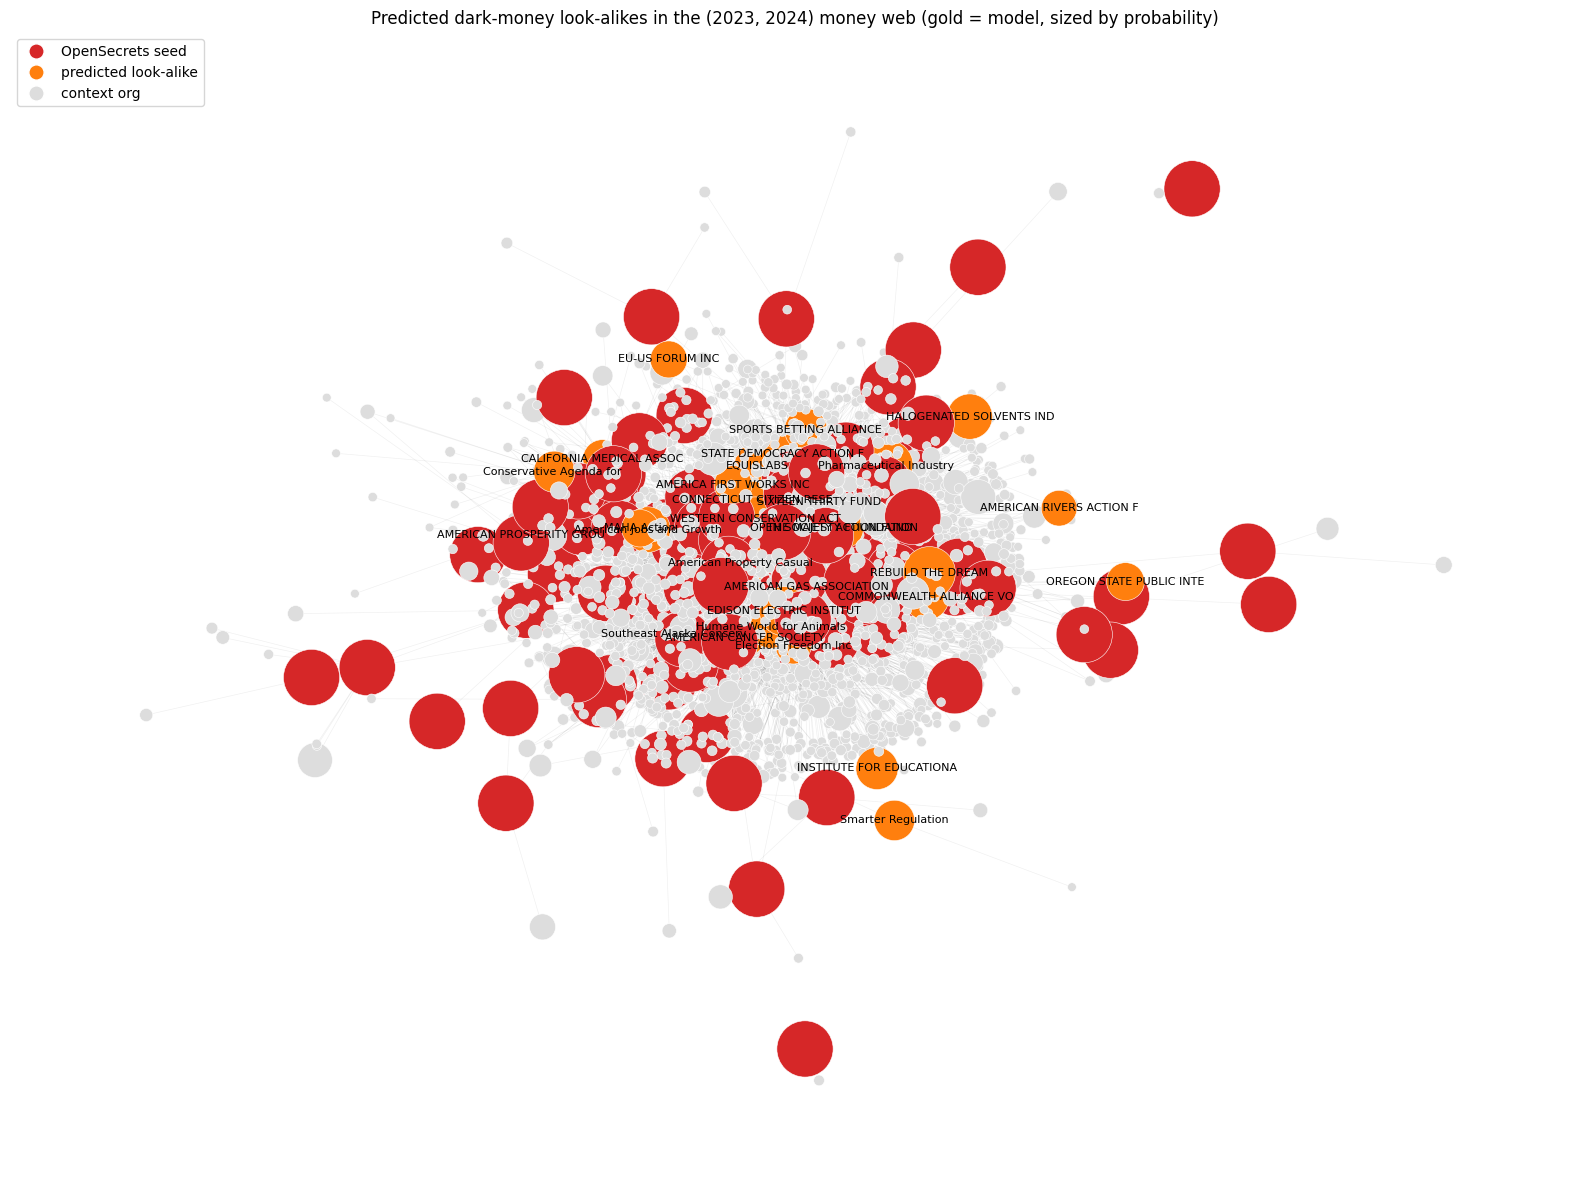

In [ ]:
# NetworkX overview: seeds (red) + predicted look-alikes (gold) in the money web, sized by model probability.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

name_of = M.set_index("ein").name.to_dict()
prob_of = M.set_index("ein").score.to_dict()
top_leads = set(leads.head(30).ein)

keep = {n for n in G.nodes if n in seed_set} | top_leads
for n in list(keep):                                   # add 1-hop context around highlighted nodes
    keep |= set(G.predecessors(n)) | set(G.successors(n))
Hp = G.subgraph(keep).copy()
Hp.remove_nodes_from([n for n in list(Hp.nodes) if Hp.degree(n) == 0])

pos = nx.spring_layout(Hp, k=0.5, seed=2, weight="weight")
color = ["#d62728" if n in seed_set else "#ff7f0e" if n in top_leads else "#dddddd" for n in Hp.nodes]
size  = np.array([1.0 if n in seed_set else prob_of.get(n, 0.0) for n in Hp.nodes])
size  = 40 + 1600 * size

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_edges(Hp, pos, alpha=0.06, width=0.5, arrows=False, ax=ax)
nx.draw_networkx_nodes(Hp, pos, node_size=size, node_color=color, edgecolors="white", linewidths=0.4, ax=ax)
nx.draw_networkx_labels(Hp, pos, labels={n: name_of.get(n, n)[:24] for n in top_leads if n in Hp.nodes},
                        font_size=8, font_color="black", ax=ax)
ax.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=11, label=l)
                   for c, l in [("#d62728", "OpenSecrets seed"), ("#ff7f0e", "predicted look-alike"),
                                ("#dddddd", "context org")]], loc="upper left", fontsize=10)
ax.set_title(f"Predicted dark-money look-alikes in the {YEARS} money web (gold = model, sized by probability)")
ax.axis("off"); plt.tight_layout(); plt.show()


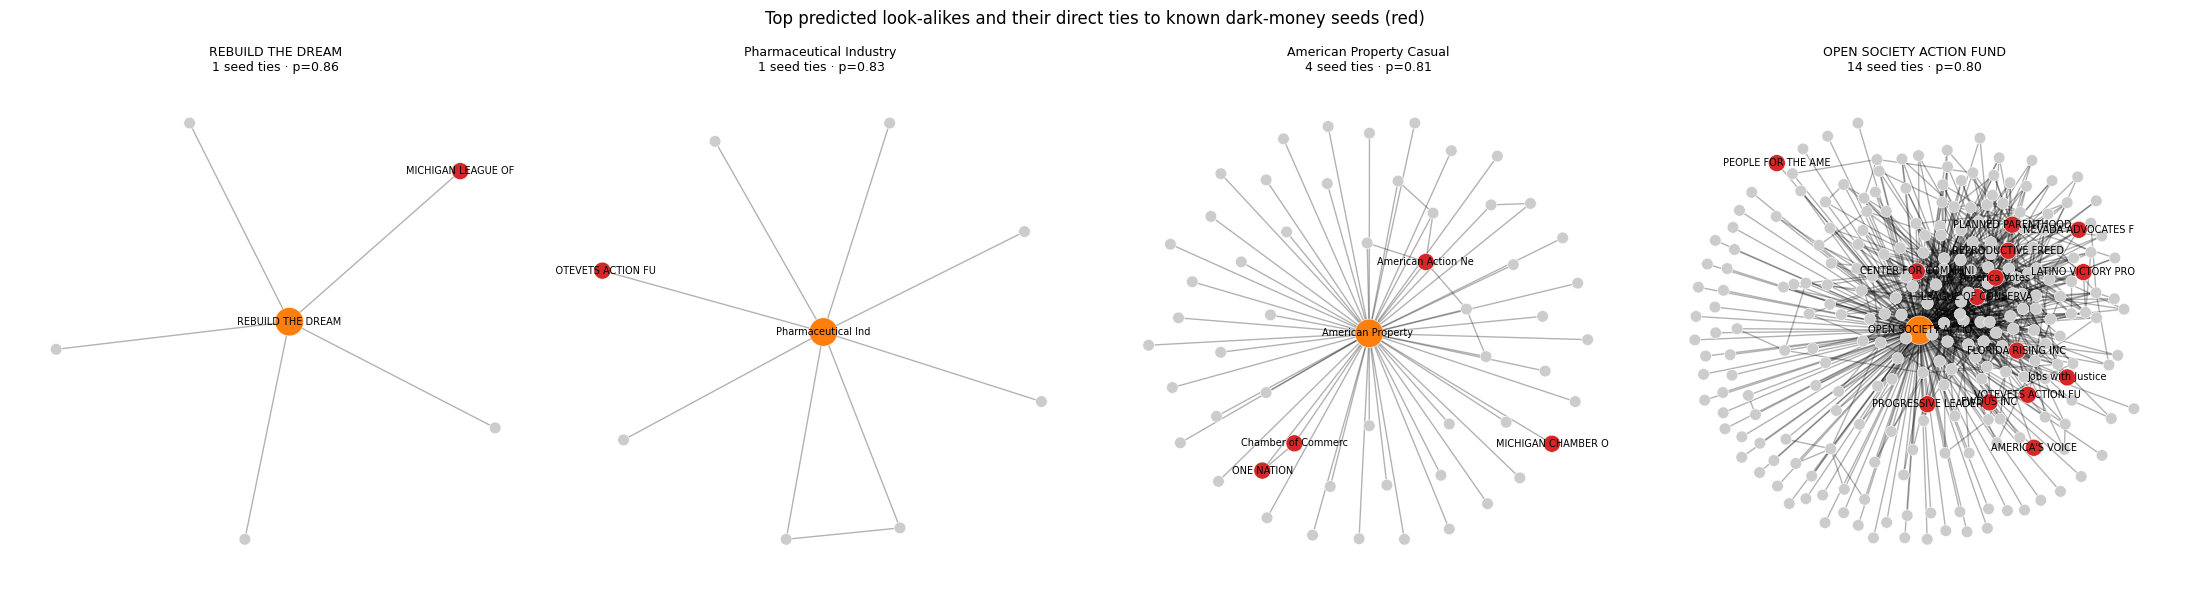

In [ ]:
# NetworkX ego close-ups: why the top look-alikes were flagged (their direct grant ties to seeds).
top_leads_list = leads.head(4).ein.tolist()
Gu = G.to_undirected()
fig, axes = plt.subplots(1, len(top_leads_list), figsize=(22, 6))
for ax, center in zip(axes, top_leads_list):
    ego = nx.ego_graph(Gu, center, radius=1)
    posE = nx.spring_layout(ego, seed=3)
    col = ["#d62728" if n in seed_set else "#ff7f0e" if n == center else "#cccccc" for n in ego.nodes]
    sz  = [420 if n == center else 150 if n in seed_set else 70 for n in ego.nodes]
    nx.draw_networkx_edges(ego, posE, alpha=0.3, ax=ax)
    nx.draw_networkx_nodes(ego, posE, node_color=col, node_size=sz, edgecolors="white", linewidths=0.4, ax=ax)
    nx.draw_networkx_labels(ego, posE, font_size=7, ax=ax,
                            labels={n: name_of.get(n, n)[:18] for n in ego.nodes if n == center or n in seed_set})
    n_seed_ties = sum(1 for nb in ego.neighbors(center) if nb in seed_set)
    ax.set_title(f"{name_of.get(center, center)[:24]}\n{n_seed_ties} seed ties · p={prob_of.get(center, 0):.2f}", fontsize=9)
    ax.axis("off")
fig.suptitle("Top predicted look-alikes and their direct ties to known dark-money seeds (red)", fontsize=12)
plt.tight_layout(); plt.show()


## Does it generalize? Hold out known dark money the model never saw

The out-of-fold scores above are already leak-free, but here is the sharper test: **hide 40% of the known OpenSecrets seeds entirely** — remove them from training *and* from the PPR personalization — then ask whether the model still floats them to the top against the hard-negative background. If unseen dark-money orgs rank high, the model has learned a transferable dark-money signature rather than memorizing the specific 113 labels.

In [ ]:
# Hold out 40% of known seeds (never trained, never in PPR); can the model still rank them above background?
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

nm_pool = dict(zip(M.ein, M.name))
seed_i = np.where(y == 1)[0]; neg_i = np.where(y == 0)[0]

def run_split(frac, rs):
    rng = np.random.default_rng(rs)
    hold = rng.choice(seed_i, size=max(1, int(frac * len(seed_i))), replace=False)
    train_seed = np.setdiff1d(seed_i, hold)
    pv = prox([nodes[i] for i in train_seed])                 # PPR proximity from TRAIN seeds only (leak-free)
    Xall = np.column_stack([Xbase, pv])
    train_rows = np.concatenate([train_seed, neg_i])          # held-out seeds excluded from training
    m = GBC().fit(Xall[train_rows], y[train_rows])
    sc = m.predict_proba(Xall)[:, 1]
    ev = np.concatenate([hold, neg_i]); ye = np.concatenate([np.ones(len(hold)), np.zeros(len(neg_i))])
    order = ev[np.argsort(-sc[ev])]; rankmap = {n: r for r, n in enumerate(order, 1)}
    rec = {k: float(np.mean([rankmap[i] <= k for i in hold])) for k in (50, 100, 200)}
    return hold, sc, rankmap, roc_auc_score(ye, sc[ev]), average_precision_score(ye, sc[ev]), rec

FRAC = 0.40
res = [run_split(FRAC, rs) for rs in range(5)]
aucs = [r[3] for r in res]; aps = [r[4] for r in res]
r50 = [r[5][50] for r in res]; r100 = [r[5][100] for r in res]; r200 = [r[5][200] for r in res]
ncand = len(neg_i) + int(FRAC * len(seed_i))
print(f"Hold out {int(FRAC*len(seed_i))}/{len(seed_i)} known dark-money orgs — never trained, never seed the PPR.")
print(f"Averaged over 5 random splits, held-out orgs vs {len(neg_i):,} hard negatives (pool ~{ncand:,}):")
print(f"  ROC-AUC   {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
print(f"  PR-AUC    {np.mean(aps):.3f} ± {np.std(aps):.3f}  (random baseline ~{len(seed_i)*FRAC/ncand:.3f})")
print(f"  recall@50 {np.mean(r50):.2f}   recall@100 {np.mean(r100):.2f}   recall@200 {np.mean(r200):.2f}")

# One split in detail: which unseen dark-money orgs did the model catch vs miss?
hold, sc, rankmap, auc, ap, rec = res[0]
val = (pd.DataFrame({"ein": [nodes[i] for i in hold], "name": [nm_pool.get(nodes[i], nodes[i]) for i in hold],
                     "score": sc[hold], "rank_of_pool": [rankmap[i] for i in hold]})
       .sort_values("score", ascending=False).reset_index(drop=True))
print(f"\nSplit 0 (AUC {auc:.3f}) — {len(hold)} unseen dark-money orgs, median score "
      f"{np.median(sc[hold]):.3f} vs negatives {np.median(sc[neg_i]):.3f}:")
display(val)


Hold out 45/113 known dark-money orgs — never trained, never seed the PPR.
Averaged over 5 random splits, held-out orgs vs 2,245 hard negatives (pool ~2,290):
  ROC-AUC   0.898 ± 0.027
  PR-AUC    0.456 ± 0.042  (random baseline ~0.020)
  recall@50 0.44   recall@100 0.55   recall@200 0.68

Split 0 (AUC 0.912) — 45 unseen dark-money orgs, median score 0.088 vs negatives 0.004:


,ein,name,score,rank_of_pool
0,651218474,POWERPAC ORG,0.988031,1
1,262731617,AMERICAN ENERGY ALLIANCE,0.987135,2
2,450710294,PATRIOT MAJORITY USA,0.943105,3
3,521312579,National Committee to Preserve Social Security...,0.894581,4
4,455542575,CITIZEN AWARENESS PROJECT INC,0.750522,5
5,455341145,UNIDOSUS ACTION FUND INC,0.710326,6
6,200748404,AMERICA'S VOICE,0.670545,7
7,460539726,BEND THE ARC JEWISH ACTION INC,0.516332,8
8,264568349,America Votes,0.408775,9
9,464126174,CATALYST OKLAHOMA INC,0.276541,10


## Ablation: what the political-neighbor feature adds

The model above now includes it, so this is the ablation that justifies it. The c6 misses earlier were trade groups (credit-union leagues, chambers, realtors) that lack the conduit money-flow shape. The **political-neighbor** feature — the share of an org's grant partners that are 501(c)(4)/(c)(6)/527 (IRS attributes, seeds removed, so leak-free) — lights up a c6 embedded in political money flow (US Chamber) while an isolated credit-union league stays low. We compare the model without vs. with it, on both out-of-fold CV and the held-out generalization.

In [ ]:
# Ablation: model WITHOUT political-neighbor (structural+behaviour) vs WITH it (Xbase, the full model).
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

Xno = M[STRUCTB + BEHAVB].fillna(0).values          # full model minus the political-neighbor block
cv = StratifiedKFold(5, shuffle=True, random_state=0)
def _oof(Xb):
    oof = np.zeros(len(nodes))
    for tr, te in cv.split(Xb, y):
        tp = [nodes[i] for i in tr if y[i] == 1]
        Xp = np.column_stack([Xb, prox(tp)])
        oof[te] = GBC().fit(Xp[tr], y[tr]).predict_proba(Xp[te])[:, 1]
    return oof
print(f"{'feature set':34s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for tag, Xb in [("PPR + base", Xno), ("PPR + base + political-neighbor", Xbase)]:
    o = _oof(Xb)
    print(f"{tag:34s} {roc_auc_score(y, o):>11.3f} {average_precision_score(y, o):>10.3f}")

seed_i = np.where(y == 1)[0]; neg_i = np.where(y == 0)[0]
def _holdout(Xb, frac=0.40):
    aucs, recs = [], []
    for rs in range(5):
        rng = np.random.default_rng(rs)
        hold = rng.choice(seed_i, size=int(frac * len(seed_i)), replace=False)
        tr_seed = np.setdiff1d(seed_i, hold)
        Xall = np.column_stack([Xb, prox([nodes[i] for i in tr_seed])])
        rows = np.concatenate([tr_seed, neg_i])
        sc = GBC().fit(Xall[rows], y[rows]).predict_proba(Xall)[:, 1]
        ev = np.concatenate([hold, neg_i]); ye = np.concatenate([np.ones(len(hold)), np.zeros(len(neg_i))])
        aucs.append(roc_auc_score(ye, sc[ev]))
        order = ev[np.argsort(-sc[ev])]; rk = {n: r for r, n in enumerate(order, 1)}
        recs.append(np.mean([rk[i] <= 200 for i in hold]))
    return np.mean(aucs), np.std(aucs), np.mean(recs)
print()
for tag, Xb in [("base", Xno), ("+ political-neighbor", Xbase)]:
    a, s, r = _holdout(Xb)
    print(f"held-out  {tag:22s} ROC-AUC {a:.3f} ± {s:.3f}   recall@200 {r:.2f}")


feature set                        OOF ROC-AUC OOF PR-AUC
PPR + base                               0.875      0.226
PPR + base + political-neighbor          0.871      0.359

held-out  base                   ROC-AUC 0.881 ± 0.014   recall@200 0.58
held-out  + political-neighbor   ROC-AUC 0.898 ± 0.027   recall@200 0.68


## Can the LDA lobbying linkage help? (using the top-of-notebook `high_conf_matches`)

The notebook opens by resolving LDA lobbying orgs to IRS EINs. Here we bridge each pool EIN back to its LDA record via `high_conf_matches` (client role) and attach lobbying intensity — number of LDA filings, distinct bills, and issue areas — then test whether it adds lift (same ablation protocol), and show it as **corroboration** on the leads.

In [ ]:
# Bridge pool EINs -> LDA lobbying record via high_conf_matches; test as features + show as corroboration.
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

conn.register("pool_eins", pd.DataFrame({"ein": nodes}))
lda = q("""
WITH pool AS (SELECT DISTINCT ein FROM pool_eins),
     ein_lda AS (SELECT DISTINCT ein, lda_key FROM high_conf_matches WHERE role = 'client'),
     cf AS (SELECT json_extract_string(raw_json, '$.client.id') AS lda_key, filing_uuid
            FROM lda_filings WHERE json_valid(raw_json)),
     agg AS (
        SELECT el.ein,
               COUNT(DISTINCT cf.filing_uuid) AS lda_n_filings,
               COUNT(DISTINCT (bl.bill_type, bl.bill_number)) AS lda_n_bills,
               COUNT(DISTINCT act.general_issue_code) AS lda_n_issues
        FROM ein_lda el JOIN cf USING (lda_key)
        LEFT JOIN lobbying_bill_links bl USING (filing_uuid)
        LEFT JOIN lda_lobbying_activities act USING (filing_uuid)
        GROUP BY el.ein)
SELECT p.ein,
       COALESCE(agg.lda_n_filings, 0) AS lda_n_filings,
       COALESCE(agg.lda_n_bills, 0)   AS lda_n_bills,
       COALESCE(agg.lda_n_issues, 0)  AS lda_n_issues,
       CASE WHEN agg.ein IS NOT NULL THEN 1 ELSE 0 END AS is_lda_client
FROM pool p LEFT JOIN agg USING (ein)
""")
Mlda = M.merge(lda, on="ein", how="left")
for c in ["lda_n_filings", "lda_n_bills", "lda_n_issues", "is_lda_client"]:
    Mlda[c] = Mlda[c].fillna(0)
Mlda["log_lda_bills"] = np.log1p(Mlda.lda_n_bills)
LDAF = ["is_lda_client", "log_lda_bills", "lda_n_issues"]

cov_pool = int((Mlda.is_lda_client == 1).sum())
cov_seed = int(((Mlda.is_lda_client == 1) & (y == 1)).sum())
print(f"LDA lobbying coverage in the pool: {cov_pool}/{len(nodes)} orgs are matched LDA clients "
      f"({cov_seed}/{int(y.sum())} seeds).")

Xlda = np.column_stack([Xbase, Mlda[LDAF].fillna(0).values])
cv = StratifiedKFold(5, shuffle=True, random_state=0)
def _oof(Xb):
    oof = np.zeros(len(nodes))
    for tr, te in cv.split(Xb, y):
        tp = [nodes[i] for i in tr if y[i] == 1]
        Xp = np.column_stack([Xb, prox(tp)])
        oof[te] = GBC().fit(Xp[tr], y[tr]).predict_proba(Xp[te])[:, 1]
    return oof
print(f"\n{'feature set':28s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for tag, Xb in [("full model", Xbase), ("full model + LDA lobbying", Xlda)]:
    o = _oof(Xb)
    print(f"{tag:28s} {roc_auc_score(y, o):>11.3f} {average_precision_score(y, o):>10.3f}")

seed_i = np.where(y == 1)[0]; neg_i = np.where(y == 0)[0]
def _holdout(Xb, frac=0.40):
    aucs = []
    for rs in range(5):
        rng = np.random.default_rng(rs)
        hold = rng.choice(seed_i, size=int(frac * len(seed_i)), replace=False)
        tr_seed = np.setdiff1d(seed_i, hold)
        Xall = np.column_stack([Xb, prox([nodes[i] for i in tr_seed])])
        rows = np.concatenate([tr_seed, neg_i])
        sc = GBC().fit(Xall[rows], y[rows]).predict_proba(Xall)[:, 1]
        ev = np.concatenate([hold, neg_i]); ye = np.concatenate([np.ones(len(hold)), np.zeros(len(neg_i))])
        aucs.append(roc_auc_score(ye, sc[ev]))
    return np.mean(aucs), np.std(aucs)
print()
for tag, Xb in [("full model", Xbase), ("full model + LDA lobbying", Xlda)]:
    a, s = _holdout(Xb)
    print(f"held-out  {tag:26s} ROC-AUC {a:.3f} ± {s:.3f}")

# Practical use: LDA lobbying as corroboration on the current leads.
print("\nTop 15 leads with LDA lobbying corroboration:")
display(leads.head(15).merge(Mlda[["ein", "is_lda_client", "lda_n_bills", "lda_n_issues"]], on="ein", how="left")
        [["ein", "name", "score", "is_lda_client", "lda_n_bills", "lda_n_issues"]])


LDA lobbying coverage in the pool: 215/2358 orgs are matched LDA clients (35/113 seeds).

feature set                  OOF ROC-AUC OOF PR-AUC
full model                         0.871      0.359
full model + LDA lobbying          0.876      0.401

held-out  full model                 ROC-AUC 0.898 ± 0.027
held-out  full model + LDA lobbying  ROC-AUC 0.897 ± 0.026

Top 15 leads with LDA lobbying corroboration:


,ein,name,score,is_lda_client,lda_n_bills,lda_n_issues
0,900741275,REBUILD THE DREAM,0.857559,0,0,0
1,431985339,Pharmaceutical Industry Labor-Management Manag...,0.831881,0,0,0
2,200487810,American Property Casualty Insurance Association,0.809600,1,5,5
3,522028955,OPEN SOCIETY ACTION FUND INC,0.799143,0,0,0
4,130659550,EDISON ELECTRIC INSTITUTE INC,0.757123,1,72,11
5,814100201,STATE DEMOCRACY ACTION FUND,0.684872,0,0,0
6,833634824,EQUISLABS,0.658847,0,0,0
7,842758628,COMMONWEALTH ALLIANCE VOTER ENGAGEMENT,0.651448,0,0,0
8,881882236,American Jobs and Growth Fund,0.650262,0,0,0
9,521434774,HALOGENATED SOLVENTS INDUSTRY ALLIANCE INC,0.640990,0,0,0


## FEC Super PAC linkage (same name + state + ZIP matcher)

FEC has no EIN, so we link committees to IRS orgs with the **same approach as the LDA↔IRS matcher**: normalize the committee name (`norm_org`), match exact + near-name (Jaro-Winkler ≥ 0.85, blocked), then grade by **state** and **ZIP** agreement. This catches the c4→affiliated-Super-PAC pattern (*Americans for Prosperity* → *Americans for Prosperity Action*) — different names but high similarity plus shared HQ state/ZIP. Payoff: the **electoral arm** — which dark-money orgs run a Super PAC and its independent expenditures.

In [24]:
# FEC Super PAC linkage: same norm-name + near-name (JW>=0.85) + state/zip grading as the LDA<->IRS matcher.
import numpy as np, pandas as pd

for _t in ("committees", "fec_disbursements"):
    conn.execute(f"""CREATE OR REPLACE VIEW {_t} AS
        SELECT * FROM read_parquet('{(ROOT / 'parquet_export' / _t / '*.parquet').as_posix()}', union_by_name=true)""")

# Committee entity: normalized name + HQ state/zip (from raw_json) + spending.
conn.execute("""
CREATE OR REPLACE TEMP TABLE fec_committees AS
SELECT committee_id,
       any_value(name) AS committee_name,
       norm_org(any_value(name)) AS normalized_name,
       any_value(committee_type) AS committee_type,
       any_value(party) AS party,
       max(UPPER(NULLIF(TRIM(json_extract_string(raw_json, '$.state')), ''))) AS fec_state,
       max(LEFT(NULLIF(TRIM(json_extract_string(raw_json, '$.zip')), ''), 5)) AS fec_zip,
       max(TRY_CAST(total_disbursements AS DOUBLE)) AS disbursements,
       max(TRY_CAST(independent_expenditures AS DOUBLE)) AS independent_expenditures
FROM committees
WHERE name IS NOT NULL AND json_valid(raw_json)
GROUP BY committee_id
""")

conn.execute(f"""
CREATE OR REPLACE TEMP TABLE fec_matches AS
WITH exact AS (
    SELECT fc.committee_id, fc.committee_name, fc.committee_type, fc.party,
           fc.disbursements, fc.independent_expenditures, irs.ein, irs.irs_name, 1.0 AS name_similarity,
           (irs.irs_state = fc.fec_state AND fc.fec_state IS NOT NULL) AS state_agrees,
           (fc.fec_zip IS NOT NULL AND fc.fec_zip = irs.irs_zip) AS zip_agrees
    FROM fec_committees fc JOIN irs_entities_addr irs USING (normalized_name)
),
near AS (
    SELECT fc.committee_id, fc.committee_name, fc.committee_type, fc.party,
           fc.disbursements, fc.independent_expenditures, irs.ein, irs.irs_name,
           jaro_winkler_similarity(fc.normalized_name, irs.normalized_name) AS name_similarity,
           (irs.irs_state = fc.fec_state AND fc.fec_state IS NOT NULL) AS state_agrees,
           (fc.fec_zip IS NOT NULL AND fc.fec_zip = irs.irs_zip) AS zip_agrees
    FROM fec_committees fc JOIN irs_entities_addr irs
      ON {name_block_on('fc.normalized_name', 'irs.normalized_name')}
     AND fc.normalized_name <> irs.normalized_name
    WHERE jaro_winkler_similarity(fc.normalized_name, irs.normalized_name) >= {NEAR_NAME_MIN_SIMILARITY}
)
SELECT * FROM exact UNION ALL SELECT * FROM near
""")

# Cycle-total spending per committee is in fec_disbursements (__CYCLE_TOTALS__ rows); IE is inside the description.
conn.execute("""
CREATE OR REPLACE TEMP TABLE fec_spend AS
SELECT committee_id,
       SUM(TRY_CAST(disbursement_amount AS DOUBLE)) AS disbursements,
       SUM(TRY_CAST(regexp_extract(disbursement_description, 'independent_expenditures=([0-9.]+)', 1) AS DOUBLE)) AS ie
FROM fec_disbursements
WHERE recipient_name = '__CYCLE_TOTALS__'
GROUP BY committee_id
""")

fec_link = q(f"""
WITH ranked AS (
    SELECT m.*, {tier_case('name')} AS tier,
           ROW_NUMBER() OVER (PARTITION BY m.committee_id
                              ORDER BY zip_agrees DESC, state_agrees DESC, name_similarity DESC, ein) AS rn
    FROM fec_matches m
    WHERE name_similarity >= {HIGH_CONF_MIN} AND (state_agrees OR zip_agrees)
)
SELECT r.ein, r.irs_name, r.committee_id, r.committee_name, r.committee_type, r.party,
       ROUND(r.name_similarity, 4) AS name_similarity, r.tier,
       COALESCE(s.ie, 0) AS ie, COALESCE(s.disbursements, 0) AS disb
FROM ranked r LEFT JOIN fec_spend s USING (committee_id)
WHERE r.rn = 1
""")
print(f"FEC committees linked to IRS EINs (sim>={HIGH_CONF_MIN}, state or zip agrees): "
      f"{fec_link.committee_id.nunique():,} committees -> {fec_link.ein.nunique():,} EINs")
print(fec_link.tier.value_counts().to_string())

# Insight: dark-money seeds + top leads that run a Super PAC, ranked by independent expenditures.
lead_eins = set(leads.head(50).ein)
dm = fec_link[fec_link.ein.isin(seed_set) | fec_link.ein.isin(lead_eins)].copy()
dm["cohort"] = np.where(dm.ein.isin(seed_set), "seed", "lead")
dm["org"] = dm.ein.map(nm)
print("\nDark-money orgs with a matched FEC Super PAC (electoral arm), by independent expenditures:")
display(dm.sort_values("ie", ascending=False)
        [["org", "cohort", "committee_name", "committee_type", "party", "name_similarity", "tier", "ie", "disb"]].head(25))


FEC committees linked to IRS EINs (sim>=0.9, state or zip agrees): 873 committees -> 796 EINs
tier
name + state    873

Dark-money orgs with a matched FEC Super PAC (electoral arm), by independent expenditures:


,org,cohort,committee_name,committee_type,party,name_similarity,tier,ie,disb
6,PLANNED PARENTHOOD/MAR MONTE,seed,PLANNED PARENTHOOD ACTION FUND OF SANT,U,None,0.9231,name + state,0.0,0.0
207,PLANNED PARENTHOOD PENNSYLVANIA ADVOCACY,seed,PLANNED PARENTHOOD SE PA ADVOCATES,U,None,0.9309,name + state,0.0,0.0
345,AMERICA FIRST WORKS INC,lead,AMERICA FIRST NETWORK,O,None,0.9609,name + state,0.0,0.0
428,FLORIDA NEW MAJORITY,seed,FLORIDA RISING PAC,O,None,1.0000,name + state,0.0,0.0
547,PLANNED PARENTHOOD PENNSYLVANIA ADVOCACY,seed,PLANNED PARENTHOOD PENNSYLVANIA VOTES,O,None,0.9805,name + state,0.0,0.0
554,PEOPLE FOR THE AMERICAN WAY,seed,PEOPLE FOR THE AMERICAN WAY VICTORY FUND,O,None,0.9407,name + state,0.0,0.0
624,AMERICAN MAJORITY ACTION,seed,AMERICAN MAJORITY ACTION PAC,O,None,1.0000,name + state,0.0,0.0
632,PEOPLE FOR THE AMERICAN WAY,seed,PEOPLE FOR AMERICAN LEADERSHIP,U,None,0.9097,name + state,0.0,0.0
648,AMERICANS FOR TAX REFORM,seed,AMERICANS FOR TAX REFORM PAC,O,None,1.0000,name + state,0.0,0.0
764,CITIZENS FOR A WORKING AMERICA,seed,CITIZENS FOR A WORKING AMERICA PAC,O,None,1.0000,name + state,0.0,0.0


In [25]:
# FEC as a modeling signal (has_fec + log independent expenditures / disbursements) + corroboration on leads.
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

fec_by_ein = (fec_link.groupby("ein")
              .agg(fec_n_committees=("committee_id", "nunique"),
                   fec_ie=("ie", "sum"), fec_disb=("disb", "sum")).reset_index())
fe = pd.DataFrame({"ein": nodes}).merge(fec_by_ein, on="ein", how="left").fillna(0)
fe["has_fec"] = (fe.fec_n_committees > 0).astype(int)
fe["log_fec_ie"] = np.log1p(fe.fec_ie); fe["log_fec_disb"] = np.log1p(fe.fec_disb)
FECF = ["has_fec", "log_fec_ie", "log_fec_disb"]
Xfec = np.column_stack([Xbase, fe[FECF].values])

cov_pool = int(fe.has_fec.sum()); cov_seed = int(((fe.has_fec == 1).values & (y == 1)).sum())
print(f"FEC committee coverage in the pool: {cov_pool}/{len(nodes)} orgs run a linked Super PAC "
      f"({cov_seed}/{int(y.sum())} seeds).")

cv = StratifiedKFold(5, shuffle=True, random_state=0)
def _oof(Xb):
    oof = np.zeros(len(nodes))
    for tr, te in cv.split(Xb, y):
        tp = [nodes[i] for i in tr if y[i] == 1]
        Xp = np.column_stack([Xb, prox(tp)])
        oof[te] = GBC().fit(Xp[tr], y[tr]).predict_proba(Xp[te])[:, 1]
    return oof
print(f"\n{'feature set':24s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for tag, Xb in [("full model", Xbase), ("full model + FEC", Xfec)]:
    o = _oof(Xb)
    print(f"{tag:24s} {roc_auc_score(y, o):>11.3f} {average_precision_score(y, o):>10.3f}")

seed_i = np.where(y == 1)[0]; neg_i = np.where(y == 0)[0]
def _holdout(Xb, frac=0.40):
    aucs = []
    for rs in range(5):
        rng = np.random.default_rng(rs)
        hold = rng.choice(seed_i, size=int(frac * len(seed_i)), replace=False)
        tr_seed = np.setdiff1d(seed_i, hold)
        Xall = np.column_stack([Xb, prox([nodes[i] for i in tr_seed])])
        rows = np.concatenate([tr_seed, neg_i])
        sc = GBC().fit(Xall[rows], y[rows]).predict_proba(Xall)[:, 1]
        ev = np.concatenate([hold, neg_i]); ye = np.concatenate([np.ones(len(hold)), np.zeros(len(neg_i))])
        aucs.append(roc_auc_score(ye, sc[ev]))
    return np.mean(aucs), np.std(aucs)
print()
for tag, Xb in [("full model", Xbase), ("full model + FEC", Xfec)]:
    a, s = _holdout(Xb)
    print(f"held-out  {tag:20s} ROC-AUC {a:.3f} ± {s:.3f}")

print("\nTop 15 leads with FEC electoral-arm corroboration ($ independent expenditures / disbursements):")
display(leads.head(15).merge(fe[["ein", "has_fec", "fec_ie", "fec_disb"]], on="ein", how="left")
        [["ein", "name", "score", "has_fec", "fec_ie", "fec_disb"]])


FEC committee coverage in the pool: 35/2358 orgs run a linked Super PAC (7/113 seeds).

feature set              OOF ROC-AUC OOF PR-AUC
full model                     0.881      0.400
full model + FEC               0.876      0.404

held-out  full model           ROC-AUC 0.861 ± 0.025
held-out  full model + FEC     ROC-AUC 0.861 ± 0.027

Top 15 leads with FEC electoral-arm corroboration ($ independent expenditures / disbursements):


,ein,name,score,has_fec,fec_ie,fec_disb
0,900741275,REBUILD THE DREAM,0.945763,0,0.0,0.0
1,921713534,OUR AMERICAN FUTURE ACTION,0.750445,0,0.0,0.0
2,130431590,AMERICAN GAS ASSOCIATION,0.702673,0,0.0,0.0
3,860140772,WHOLESALE & SPECIALTY INSURANCE ASSOCIATION,0.677392,0,0.0,0.0
4,930855897,OREGON STATE PUBLIC INTEREST RESEARCH GROUP INC,0.651727,0,0.0,0.0
5,463083014,POPULATION CONNECTION ACTION FUND,0.649509,0,0.0,0.0
6,843646174,A BETTER WISCONSIN TOGETHER INC,0.628232,0,0.0,0.0
7,431985339,Pharmaceutical Industry Labor-Management Manag...,0.594446,0,0.0,0.0
8,833634824,EQUISLABS,0.594165,0,0.0,0.0
9,541641185,INSTITUTE FOR EDUCATIONAL REFORM INC,0.532775,0,0.0,0.0


In [29]:
# Pull LIVE FEC totals for the dark-money-linked committees only (DEMO_KEY is rate-limited ~30/hr, so just this subset).
import os, time, requests, pandas as pd

FEC_KEY = os.environ.get("FEC_API_KEY") or "DEMO_KEY"
cids = sorted(dm.committee_id.unique().tolist())
print(f"Pulling FEC totals for {len(cids)} linked committees (key={'REAL' if FEC_KEY != 'DEMO_KEY' else 'DEMO_KEY'})...")

rows = []
for cid in cids:
    try:
        r = requests.get(f"https://api.open.fec.gov/v1/committee/{cid}/totals/",
                         params={"api_key": FEC_KEY, "sort": "-cycle", "per_page": 100}, timeout=30)
        if r.status_code != 200:
            rows.append((cid, None, None, None, f"HTTP {r.status_code}")); continue
        res = r.json().get("results", []) or []
        disb = sum(float(x.get("disbursements") or 0) for x in res)
        ie   = sum(float(x.get("independent_expenditures") or 0) for x in res)
        rcpt = sum(float(x.get("receipts") or 0) for x in res)
        cyc  = ", ".join(str(x.get("cycle")) for x in res[:5])
        rows.append((cid, disb, ie, rcpt, cyc))
    except Exception as e:
        rows.append((cid, None, None, None, str(e)[:40]))
    time.sleep(0.4)

fec_api = pd.DataFrame(rows, columns=["committee_id", "api_disb", "api_ie", "api_receipts", "cycles"])
out = dm.merge(fec_api, on="committee_id", how="left").sort_values("api_ie", ascending=False, na_position="last")
print("\nDark-money electoral arm with LIVE FEC totals (all cycles summed):")
display(out[["org", "cohort", "committee_name", "committee_type", "party",
             "api_receipts", "api_disb", "api_ie", "cycles"]].head(25))


Pulling FEC totals for 12 linked committees (key=REAL)...

Dark-money electoral arm with LIVE FEC totals (all cycles summed):


,org,cohort,committee_name,committee_type,party,api_receipts,api_disb,api_ie,cycles
9,CITIZENS FOR A WORKING AMERICA,seed,CITIZENS FOR A WORKING AMERICA PAC,O,None,3389843.84,3389843.84,3253983.59,"2020, 2018, 2016, 2014, 2012"
0,PLANNED PARENTHOOD/MAR MONTE,seed,PLANNED PARENTHOOD ACTION FUND OF SANT,U,None,0.00,0.00,0.00,
2,AMERICA FIRST WORKS INC,lead,AMERICA FIRST NETWORK,O,None,0.00,0.00,0.00,
1,PLANNED PARENTHOOD PENNSYLVANIA ADVOCACY,seed,PLANNED PARENTHOOD SE PA ADVOCATES,U,None,0.00,0.00,0.00,
3,FLORIDA NEW MAJORITY,seed,FLORIDA RISING PAC,O,None,419.30,419.30,0.00,2016
4,PLANNED PARENTHOOD PENNSYLVANIA ADVOCACY,seed,PLANNED PARENTHOOD PENNSYLVANIA VOTES,O,None,0.00,0.00,0.00,"2022, 2020, 2018"
6,AMERICAN MAJORITY ACTION,seed,AMERICAN MAJORITY ACTION PAC,O,None,6818184.00,1964566.33,0.00,2026
5,PEOPLE FOR THE AMERICAN WAY,seed,PEOPLE FOR THE AMERICAN WAY VICTORY FUND,O,None,0.00,0.00,0.00,"2022, 2020"
7,PEOPLE FOR THE AMERICAN WAY,seed,PEOPLE FOR AMERICAN LEADERSHIP,U,None,0.00,0.00,0.00,
8,AMERICANS FOR TAX REFORM,seed,AMERICANS FOR TAX REFORM PAC,O,None,89197.44,89197.44,0.00,"2018, 2016, 2014"


In [30]:
# Sweep ALL linked FEC committees with the live key and persist to S3 as fec_live_committee_totals
# (distinct name so it's obvious this came from the live openFEC API, not the DB snapshot).
import os, time, requests, pandas as pd, datetime as _dt

FEC_KEY = os.environ.get("FEC_API_KEY") or "DEMO_KEY"
assert FEC_KEY != "DEMO_KEY", "Set FEC_API_KEY in the kernel first (real key needed for the full sweep)."

all_cids = sorted(fec_link.committee_id.unique().tolist())
print(f"Sweeping {len(all_cids)} linked committees via live FEC API (~{len(all_cids)*0.4/60:.1f} min)...")

def _get_totals(cid, tries=4):
    for attempt in range(tries):
        r = requests.get(f"https://api.open.fec.gov/v1/committee/{cid}/totals/",
                         params={"api_key": FEC_KEY, "sort": "-cycle", "per_page": 100}, timeout=30)
        if r.status_code == 200:
            return r.json().get("results", []) or [], None
        if r.status_code == 429:                       # rate limited: exponential backoff then retry
            time.sleep(2 ** attempt); continue
        return None, f"HTTP {r.status_code}"
    return None, "HTTP 429 (exhausted retries)"

rows = []
for i, cid in enumerate(all_cids, 1):
    try:
        res, err = _get_totals(cid)
        if err:
            rows.append((cid, None, None, None, None, err))
        else:
            rows.append((cid,
                         sum(float(x.get("receipts") or 0) for x in res),
                         sum(float(x.get("disbursements") or 0) for x in res),
                         sum(float(x.get("independent_expenditures") or 0) for x in res),
                         len(res),
                         ", ".join(str(x.get("cycle")) for x in res[:8])))
    except Exception as e:
        rows.append((cid, None, None, None, None, str(e)[:40]))
    if i % 100 == 0:
        print(f"  {i}/{len(all_cids)}")
    time.sleep(0.4)

fec_live = (pd.DataFrame(rows, columns=["committee_id", "api_receipts", "api_disb",
                                        "api_ie", "n_cycles", "cycles"])
            .merge(fec_link[["committee_id", "committee_name", "committee_type", "party",
                             "ein", "irs_name", "name_similarity", "tier"]].drop_duplicates("committee_id"),
                   on="committee_id", how="left"))
fec_live["is_seed"] = fec_live.ein.isin(seed_set).astype(int)
fec_live["pulled_at"] = _dt.datetime.utcnow().isoformat()

ok = fec_live.api_receipts.notna().sum()
print(f"\nPulled {ok}/{len(fec_live)} committees ok; "
      f"total live receipts ${fec_live.api_receipts.sum():,.0f}, "
      f"disbursements ${fec_live.api_disb.sum():,.0f}, "
      f"independent expenditures ${fec_live.api_ie.sum():,.0f}")

# Persist to S3 parquet under a clearly-named prefix (live-API provenance).
out_path = f"{PARQUET_BASE}/fec_live_committee_totals/fec_live_committee_totals.parquet"
conn.register("fec_live_df", fec_live)
conn.execute(f"COPY fec_live_df TO '{out_path}' (FORMAT PARQUET)")
print(f"\nWrote {len(fec_live):,} rows to {out_path}")

print("\nTop 20 linked committees by live independent expenditures:")
display(fec_live.sort_values("api_ie", ascending=False)
        .head(20)[["irs_name", "committee_name", "is_seed", "api_receipts",
                   "api_disb", "api_ie", "n_cycles"]])


Sweeping 873 linked committees via live FEC API (~5.8 min)...
  100/873
  200/873
  300/873
  400/873
  500/873
  600/873
  700/873
  800/873


KeyboardInterrupt: 